# 4D Flight Optimization

Given an origin-destination pair, a takeoff time, and an aircraft type, we can search for the trajectory that minimizes an airline's cost of flying it. We call this **4D flight optimization**: the optimizer lays out a sequence of waypoints in latitude, longitude, altitude, and time, choosing a flight level and Mach number along the way to minimize a combined fuel + time + climate cost.

This notebook works through a complete end-to-end example of 4D flight optimization, for a single flight from Boston to Seattle.

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from pycontrails import DiskCacheStore, Flight
from pycontrails.datalib.google_forecast import GoogleForecast
from pycontrails.physics import units

import contrailopt as co

## Flight

Specify the flight to optimize: an origin-destination pair, a takeoff time, and an aircraft type. The cost index, which sets the fuel-versus-time tradeoff, is chosen later when solving.

In [2]:
origin = co.AirportCoords.from_icao("KBOS")
dest = co.AirportCoords.from_icao("KSEA")

aircraft_type = "B737"

takeoff_time = pd.Timestamp("2026-03-07T02:00:00")

## Weather

We use ERA5 reanalysis from the public [ARCO-ERA5](https://github.com/google-research/arco-era5) archive, which requires no credentials. It supplies the air temperature and winds that drive aircraft performance and ground speed during optimization.

Both the weather and the contrail forecast are easier to handle if we downselect in time first. This requires an upper bound on the flight duration, which we estimate below.

In [3]:
flight_hours = co.estimate_flight_hours(origin, dest)

t0 = takeoff_time
t1 = t0 + pd.Timedelta(hours=flight_hours)

In [4]:
data_vars = {
    "temperature": "air_temperature",
    "u_component_of_wind": "eastward_wind",
    "v_component_of_wind": "northward_wind",
}

arco_store = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
arco_ds = xr.open_zarr(arco_store, chunks=None)

# Select required variables, rename for pycontrails, downselect in time
met = arco_ds[list(data_vars)].rename(data_vars).sel(time=slice(t0, t1))

## Contrail forecast

The climate term needs gridded contrail forcing data analogous to weather: effective energy forcing, in joules per meter of flight. We use the [Google Contrails Forecast API](https://developers.google.com/contrails), which requires an API key.

In [5]:
gf = GoogleForecast(time=(t0, t1), variables="eeef_per_m", cachestore=DiskCacheStore())
eef = gf.open_metdataset()["expected_effective_energy_forcing"]

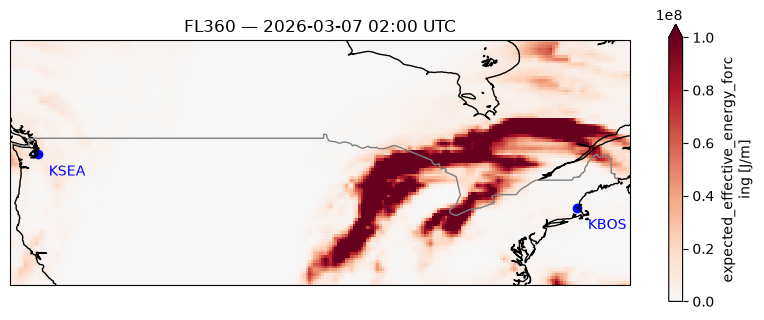

In [ ]:
# Plot a slice at FL360 for demonstration purposes
eef_slice = eef.data.sel(level=units.ft_to_pl(36000), time=takeoff_time, method="nearest")

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "RdBu_r_warm", mpl.colormaps["RdBu_r"](np.linspace(0.5, 1.0, 256))
)

_, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(10, 6))
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor="gray")
eef_slice.plot.pcolormesh(
    x="longitude",
    y="latitude",
    ax=ax,
    cmap=cmap,
    vmin=0,
    vmax=1e8,
    extend="max",
    cbar_kwargs={"shrink": 0.6},
)

for ap in (origin, dest):
    ax.scatter(*ap.coords, color="blue")
    ax.text(
        ap.longitude + 1.0,
        ap.latitude - 2.0,
        ap.icao_code,
        color="blue",
    )

ax.set_title(f"FL360 — {takeoff_time:%Y-%m-%d %H:%M} UTC")
ax.set_extent([-125, -66, 35, 55]);

## Cost optimization

We build an `Optimizer` from the route, the weather, and the contrail forecast, then solve it. Constructing the optimizer is the most expensive step: it lays out the candidate waypoint graph and interpolates the gridded data onto its edges. Solving is comparatively cheap, and the cost settings can be varied between calls without rebuilding the full optimizer.

In [7]:
opt = co.Optimizer(
    origin_icao=origin,
    dest_icao=dest,
    takeoff_time=takeoff_time,
    met=met,
    eef=eef,
    aircraft_type=aircraft_type,
    rng=np.random.default_rng(1234),  # reproducibility
)

opt

Optimizer(KBOS -> KSEA, B737, 2026-03-07 02:00:00, 453 nodes, with met, unsolved)

In [8]:
# The opt.solve method returns low-level information involved
# during the algorithm runtime.
res = opt.solve(cost_index=30)

# Calling to_flight generates the actual flight plan as a pycontrails.Flight
fl_opt = opt.to_flight()
fl_opt.attrs["total_fuel_burn"] = res.trip_fuel  # used later

fl_opt

Flight [11 keys x 172 length, 2 attributes]
	Keys: mach_number, air_temperature, u_wind, v_wind, node_index, ..., altitude_ft
	Attributes:
	time                [2026-03-07 02:00:00, 2026-03-07 07:11:04.341796875]
	longitude           [-122.30999755859375, -71.00800323486328]
	latitude            [42.36199951171875, 48.39500045776367]
	altitude            [6.099999904632568, 12192.0]
	aircraft_type       B737
	total_fuel_burn     12686.153343008664

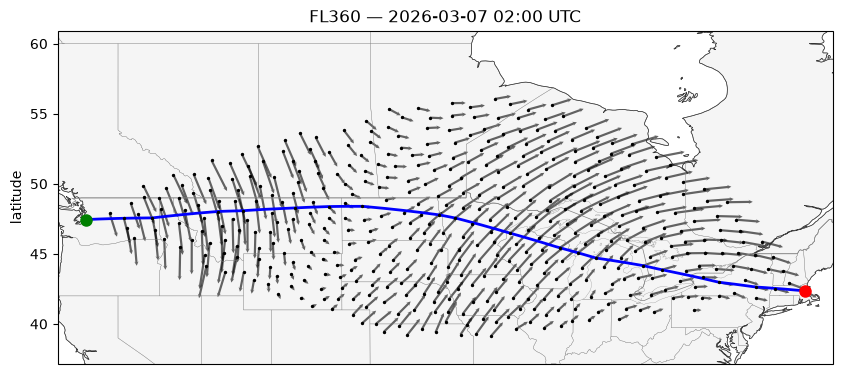

In [9]:
ax = opt.plot_met(altitude_ft=36000, show_eef=False)
fl_opt.plot(ax=ax, linewidth=2, color="blue")
ax.get_figure().set_size_inches(10, 6)

## Sweep the cost index

The cost index sets what a minute of flight time is worth in kilograms of fuel. The sweep below is one example of a simulation you can run with a built optimizer. We re-solve at three values, reusing the optimizer from above. We compare the fuel vs time tradeoff and visualize resulting routes and vertical profiles.

The three routes diverge over a portion of the flight, and the step-climb schedules differ throughout the cruise.

In [10]:
fls = []
summaries = {}
for cost_index in [0, 20, 60]:
    res = opt.solve(cost_index=cost_index)
    fl = opt.to_flight()
    fl.attrs["cost_index"] = cost_index
    fls.append(fl)

    summaries[f"cost index {cost_index}"] = {
        "fuel_kg": res.trip_fuel,
        "duration_minutes": fl.duration.total_seconds() / 60.0,
    }

# Display a DataFrame for presentation only
pd.DataFrame.from_dict(summaries, orient="index").round(1)

,fuel_kg,duration_minutes
cost index 0,12476.4,328.1
cost index 20,12602.0,314.2
cost index 60,12984.5,304.8


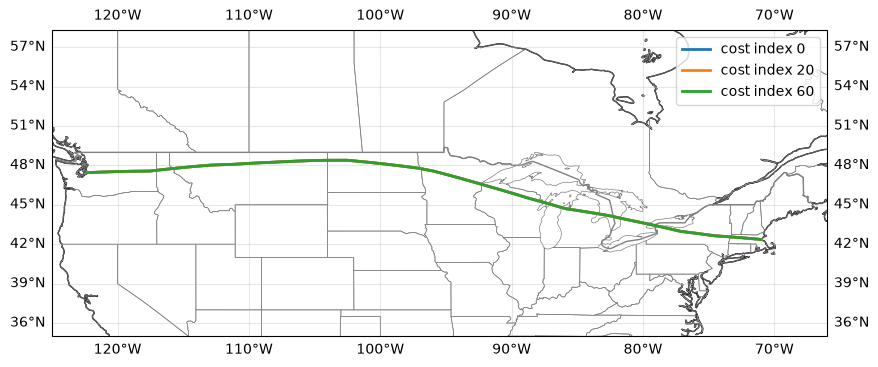

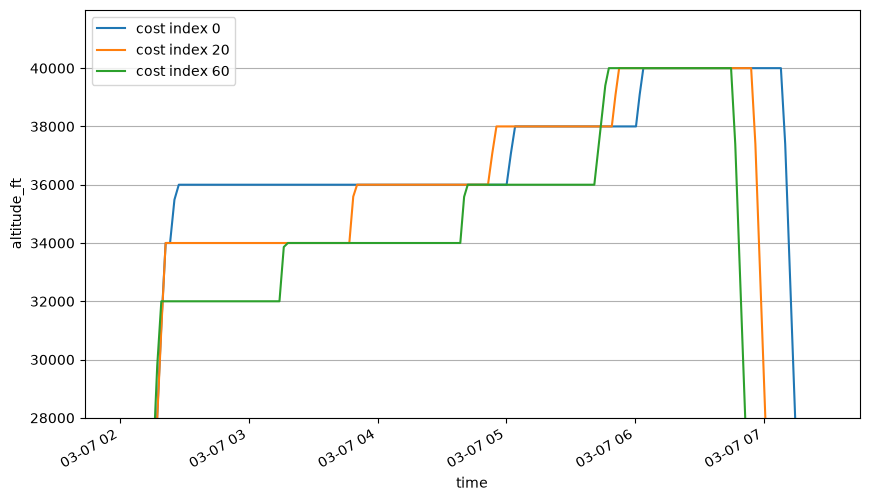

In [11]:
_, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor="gray")
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=True, alpha=0.3)

for fl in fls:
    ax.plot(
        fl["longitude"],
        fl["latitude"],
        transform=ccrs.PlateCarree(),
        linewidth=2,
        label=f"cost index {fl.attrs['cost_index']}",
    )
ax.set_extent([-125, -66, 35, 55])
ax.legend()
plt.show()


_, ax = plt.subplots(figsize=(10, 6))
for fl in fls:
    fl.plot_profile(ax=ax, label=f"cost index {fl.attrs['cost_index']}")

ax.set_yticks(opt.fl_choices)
ax.set_ylim(28000, 42000)
ax.grid(True, axis="y")
ax.legend()
plt.show()

## Contrail-aware optimization

Aviation warms the climate in two main ways: CO2 released by burning jet fuel, and radiative forcing from contrails. The two act on very different timescales. CO2 persists for centuries to millennia, altering the radiative balance continuously. Contrails last hours, but force far more strongly while they do. By historical coincidence, aviation's warming to date is split roughly evenly between the two.

A climate-aware optimizer has to trade one against the other. We price contrail energy forcing as a CO2-equivalent mass and charge `dollar_tonne_co2e` for it, alongside the CO2 from the fuel the trajectory burns. The conversion rests on AGWP-style metrics. While imperfect, they make the tradeoff explicit.

In [12]:
res = opt.solve(cost_index=30, dollar_tonne_co2e=10)

fl_opt_con = opt.to_flight()
fl_opt_con.attrs["total_fuel_burn"] = res.trip_fuel  # used later

fl_opt_con

Flight [11 keys x 172 length, 2 attributes]
	Keys: mach_number, air_temperature, u_wind, v_wind, node_index, ..., altitude_ft
	Attributes:
	time                [2026-03-07 02:00:00, 2026-03-07 07:08:43.404296875]
	longitude           [-122.30999755859375, -71.00800323486328]
	latitude            [42.36199951171875, 48.39500045776367]
	altitude            [6.099999904632568, 12192.0]
	aircraft_type       B737
	total_fuel_burn     12845.543968008657

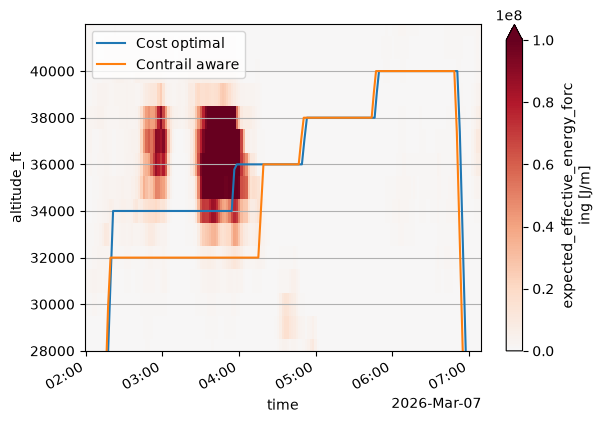

In [13]:
ax = fl_opt.plot_profile(label="Cost optimal")
fl_opt_con.plot_profile(ax=ax, label="Contrail aware")

eef_curtain = fl_opt_con.intersect_met_cross_section(eef)
eef_curtain.plot.pcolormesh(
    x="time",
    y="altitude_ft",
    ax=ax,
    cmap=cmap,
    vmin=0,
    vmax=1e8,
    extend="max",
)

ax.set_yticks(opt.fl_choices)
ax.set_ylim(28000, 42000)
ax.grid(True, axis="y")
ax.legend()
plt.show()


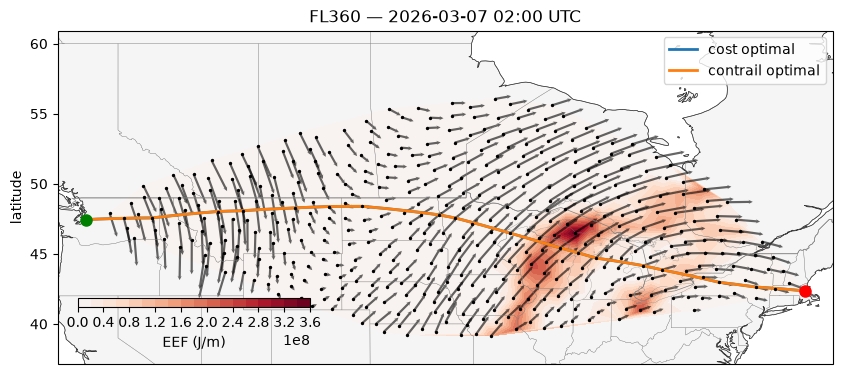

In [14]:
ax = opt.plot_met(altitude_ft=36000, time=takeoff_time)
fl_opt.plot(ax=ax, linewidth=2, label="cost optimal")
fl_opt_con.plot(ax=ax, linewidth=2, label="contrail optimal")
ax.legend()
ax.get_figure().set_size_inches(10, 6);

### The cost of contrail mitigation

The table below shows the tradeoff between estimated contrail warming, time, and fuel. Pricing contrails at $10 per tonne of CO2e removes the majority of the trajectory's contrail forcing at the expense of a small fuel penalty. Because the contrail optimal route flies below a contrail forcing region rather than climbing through it, it flies in warmer air, and the total flight duration ends up slightly shorter than that of the cost-optimal route.

In [15]:
def summarize(fl: Flight) -> dict[str, float]:
    """Summarize the contrail forcing, fuel burn, and duration of a solved trajectory."""
    seg_eef = fl["eef_per_m"] * fl.segment_length()

    return {
        "eef_TJ": np.nansum(seg_eef).item() / 1e12,
        "fuel_kg": fl.attrs["total_fuel_burn"],
        "duration_minutes": fl.duration.total_seconds() / 60.0,
    }


# Display a DataFrame for presentation only
pd.DataFrame.from_dict(
    {
        "cost optimal": summarize(fl_opt),
        "contrail aware": summarize(fl_opt_con),
    },
    orient="index",
).round(1)

,eef_TJ,fuel_kg,duration_minutes
cost optimal,51.6,12686.2,311.1
contrail aware,6.0,12845.5,308.7
